In [1]:
# Add module to path
import os
import sys
module_path = os.path.abspath(os.path.join('../..'))
if module_path not in sys.path:
    sys.path.append(module_path)

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from tqdm import tqdm
from matplotlib.colors import TABLEAU_COLORS
from scipy.signal import convolve2d
from scipy.stats import norm

from darts.dartboards import generate_dartboard, DARTBOARD_CONSTANTS
from darts.stats import expected_score, std_score, gaussian_filter

### How do I throw high scoring darts?

This post draws on methods outlined in the paper [A Statistician Plays Darts](https://www.stat.cmu.edu/~ryantibs/papers/darts.pdf), by Ryan J. Tibshirani, Andrew Price and Jonathan Taylor. I will refer to the paper as ASPD for the rest of the post.

Consider a player (Alice) throwing darts at the standard dart board. In a normal game (or leg in a professional match), Alice starts with a score of 501, and each score from a throw of a dart is taken off of the player's total. Therefore, at least in the early stages of the game, she is seeking to maximise the score of each dart. A good player will obviously aim for the highest scoring regions of the board (the triple 20, the bullseye, the triple 19). However, this may not be a good strategy for an amateur player - for example, the triple 20 region is surrounded by low scoring regions (in the 1 and 5 segments). This means that they may be better off aiming at a lower scoring region, which is surrounded by regions of similar score, so as to minimise the risk of hitting these regions due to a less accurate aim.

How should we quantify Alice's ability? To start with, let's make the simplifying assumption that when she aims at a particular point on the dartboard $p$, the probability of the dart hitting the board at a specific location $Z$ is given by a 2-D spherical Gaussian distribution:

$$
Z\sim N(p, \sigma^2 \mathbf{I})
$$

The parameter $\sigma$ is the standard deviation of the throw, and parameterises the skill level of the player. This is the initial assumption made in ASPD; later, we will follow the lead of ASPD in generalising this to a general covariance matrix $\Sigma$.



$Z$ is a random variable, taking values in $\mathbb{R}\times\mathbb{R}$; the score of the dart is a function $s:Z\mapsto s(Z)\in \mathbb{N}_0$, returning the score of the region of the dartboard that the dart hit. This is what the scoring function looks like, applied to each region of the dartboard:

In [3]:
board, _ = generate_dartboard(2048)
mm_per_pixel = 2*DARTBOARD_CONSTANTS['DARTBOARD_RADIUS_MM']/2048

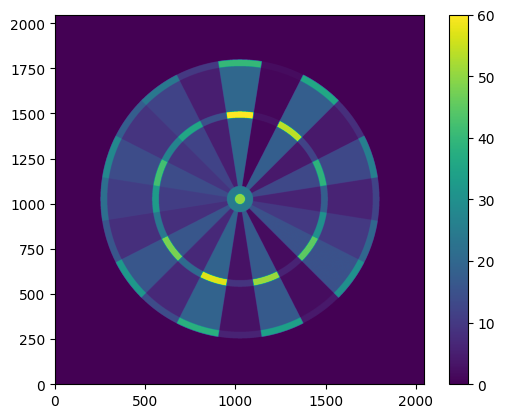

In [4]:
plt.imshow(board, origin='lower')
plt.colorbar()

Suppose that Alice aims at a point $p$ on the board, with throwing distribution $Z\sim N(p, \sigma^2 \mathbf{I})$. The key insight of ASPD is that the expected score of the dart is given by a convolution of a Gaussian probability density function (pdf) and the scoring function $s$:

$$
\begin{align}
\mathbf{E}_{p,\sigma}\left[s(Z)\right] &= \int_{\mathbb{R}\times\mathbb{R}}f_{p,\sigma}(x, y)s(x, y)\;\mathrm{d}x\mathrm{d}y \\
&= \left(f_{0,\sigma}*s\right)(p)
\end{align}
$$

where $f_{p,\sigma}$ is the probability density function of a 2-D Gaussian random variable with mean $p$ and covariance matrix $\sigma^2\mathbf{I}$. This convolution can be computed easily by taking advantage of the identity:

$$
f*g = \mathcal{F}^{-1}\left[\mathcal{F}(f)\cdot\mathcal{F}(g)\right]
$$

where $\mathcal{F}(f)$ is the Fourier transform of the function $f$. This can be efficiently computed for all positions $p$ on the board, using the fast Fourier transform (FFT), an algorithm available out of the box from many scientific programming libraries such as [numpy](https://numpy.org/doc/stable/index.html).

Let's start be recreating some of the heat plots produced in ASPD, using a range of $\sigma$ values to represent players of different abilities. The temperature of the heat plot indicates the expected score obtained when aiming at that point; also marked is the maximum expected value, i.e. the point at which the player should aim to maximise the expected score.

In [5]:
def plot_heat_map(sigma_mms, board, mm_per_pixel, plot_shape=None, fig_args=None):
    plot_shape = plot_shape or (len(sigma_mms), 1)
    fig_args = fig_args or {}
    fig, axes = plt.subplots(nrows=plot_shape[0], ncols=plot_shape[1], **fig_args)
    
    # Used to plot the dartboard region borders
    borders = convolve2d(board, np.array([[1,1,1],[1,-8,1],[1,1,1]]), mode='same')
    borders = borders != 0
    
    for ax, sigma_mm in zip(axes.flat, sigma_mms):
        # Convert sigma units
        sigma_pxl = sigma_mm / mm_per_pixel

        # Define throwing distribution
        mu = np.array([0, 0])
        Sigma = sigma_pxl * sigma_pxl * np.eye(2)

        # Expected score
        exp = expected_score(board, mu, Sigma, padding=100)
        i, j = np.unravel_index(np.argmax(exp), board.shape)
        
        # Plot the heat maps
        im = ax.imshow(exp + 60*borders, origin='lower', vmin=0, vmax=60)
        ax.scatter(j, i, color='red')
        ax.axis('off')
        ax.set_title(f'sigma = {sigma_mm}')
    
    fig.tight_layout() 
    fig.colorbar(im, ax=axes.ravel().tolist())

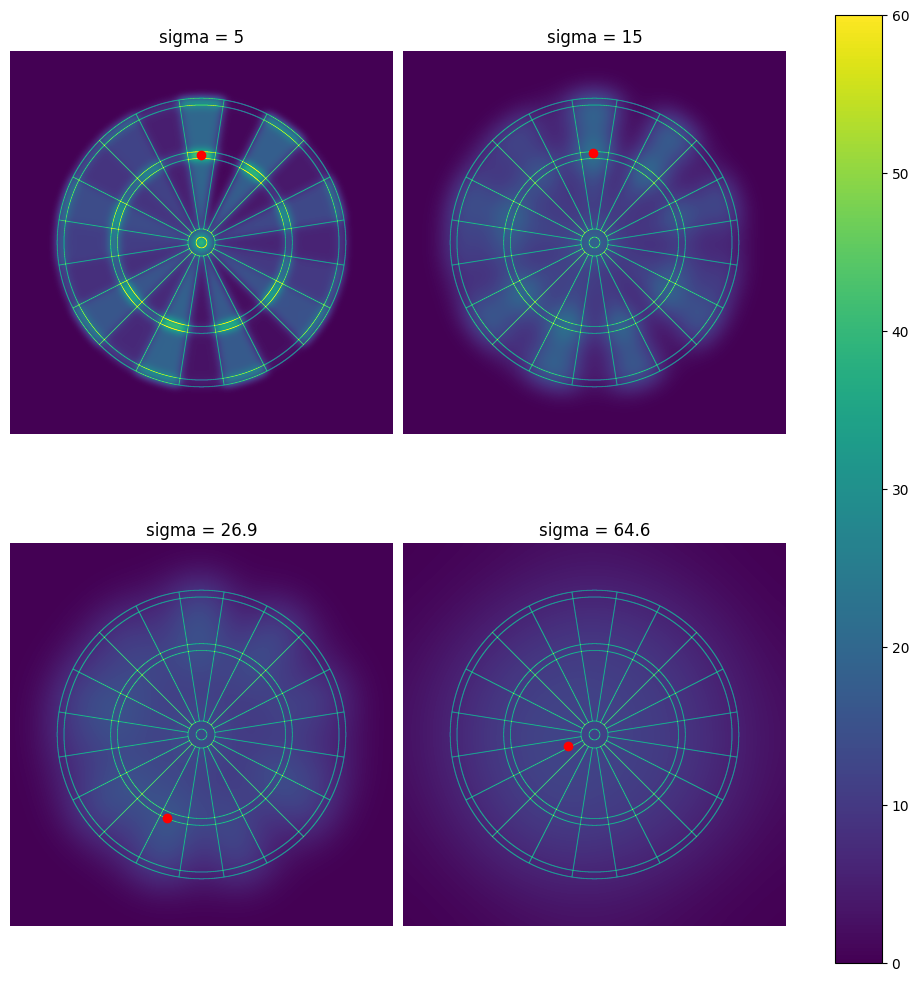

In [6]:
plot_heat_map([5, 15, 26.9, 64.6], board, mm_per_pixel, plot_shape=(2,2), fig_args={'figsize': (10, 10)})

We see from these plots that strong players should aim for the triple 20 to maximise their 1-dart score. Below a certain skill threshold, this switches over to the triple 19. As the throwing distribution gets more and more spread (i.e. as $\sigma$ increases), the optimal aim spot moves closer to the bullseye. As the skill of the player decreases, the maximum expected score that the player can expect to achieve also decreases.

The visualizations above have been used to find the optimal aiming points for 4 specific values of $\sigma$. Instead, let's look at a range of possible values, and identify the optimial aiming point, the maximum expected score, and the standard deviation of the score when aiming for this point:

In [18]:
mu = np.array([0, 0])
Sigma = np.array([[1, 0], [0, 1]])

coords = []
exps = []
stds = []

sigma_range = np.linspace(0.1, 70, 200)

for sigma_mm in tqdm(sigma_range):
    sigma_pxl = sigma_mm / mm_per_pixel
    exp = expected_score(board, mu, sigma_pxl*sigma_pxl*Sigma, padding=200)
    std = std_score(board, mu, sigma_pxl*sigma_pxl*Sigma, padding=200)

    # Coordinates of maximum expected score
    i, j = np.unravel_index(exp.argmax(), exp.shape)
    
    exps.append(np.max(exp))
    stds.append(std[i, j])
    coords.append((j, i))

100%|████████████████████████████████████████████████████████████████████████████████| 200/200 [14:52<00:00,  4.46s/it]


In [19]:
exp_df = pd.DataFrame(list(zip(sigma_range, exps, stds, coords)), 
                      columns=['sigma', 'exp_score', 'std_score', 'exp_coords']
                     ).set_index('sigma')

In [56]:
def plot_col_against_sigma(col, coords_col, df, board, additional_cols=None, ax=None, max_col=None, fig_args=None):
    additional_cols = additional_cols or []
    fig_args = fig_args or {}
    if ax is None:
        fig, ax = plt.subplots(1, **fig_args)
        
    ax.plot([0], [0], c='black', label='Expected score')
    ax.plot([0], [0], c='black', linestyle=':', label='Standard deviation')
    
    df = df[~df[col].isna()]
    if max_col:
        df = df[df[col] < max_col]
    
    board_score = df[coords_col].apply(lambda x: board[x[1], x[0]])
    groups = (board_score.diff() != 0).cumsum()
    a = pd.concat([df, groups, board_score], axis=1)
    
    for group in groups.unique():
        color = list(TABLEAU_COLORS.values())[(group-1) % 10]
        this_df = a[groups == group]
        this_df[col].plot(c=color, ax=ax, label=f'Aim: {int(this_df.iloc[0, -1])}')
        for add_col in additional_cols:
            this_df[add_col].plot(c=color, style=':', ax=ax, label='_nolegend_')
    
    ax.grid()
    ax.legend()
    ax.set_ylabel('Points')
    return ax

<Axes: xlabel='sigma', ylabel='Points'>

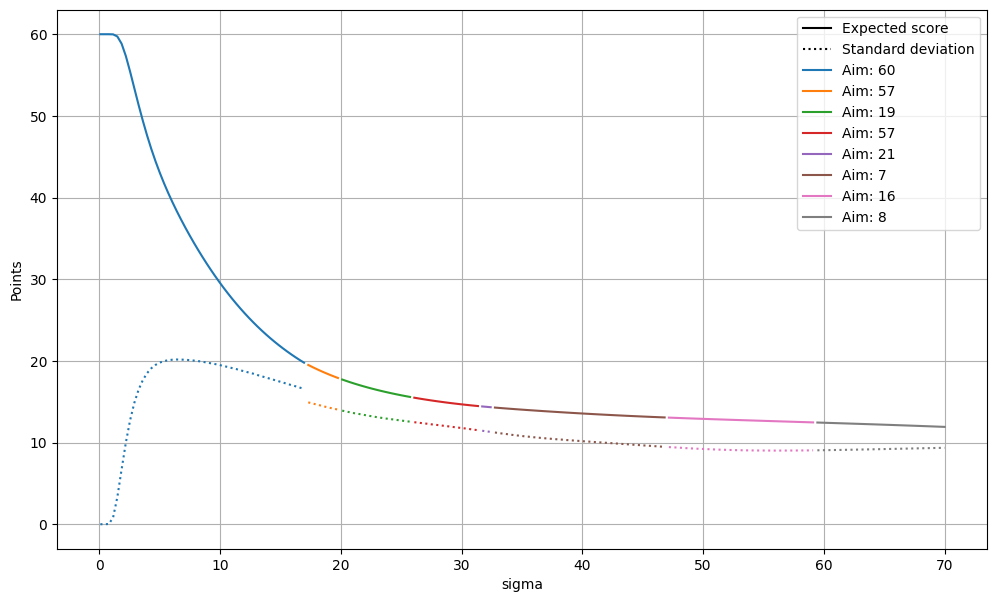

In [57]:
plot_col_against_sigma('exp_score', 'exp_coords', exp_df, board, ['std_score'], fig_args={'figsize': (12, 7)})

The takeaways from this plot are:
- For players with $\sigma<17$ millimetres, the triple 20 is the best place to aim. As $\sigma$ rises from 0, the standard deviation of the expected score rises until it reaches a maximum at $\sigma=6.5$ millimetres, after which it begins to decrease. Expected scores decrease from the maximum of 60 (for players with near perfect aim) down to 20 as $\sigma$ increases.


- At $\sigma\approx 17$ millimetres, the optimal aim point makes a discontinuous jump to the triple 19. The exact aim point is not always in the triple 19 region - for example, it drifts slightly outside the triple 19 region into the single 19 region, taking advantage of the larger area of the outer single 19 region. Expected scores for players with this skill level are in the 15-20 point range.


- As $\sigma$ increases further, the optimal point drifts upwards and closer to the bullseye, to minimise the probability of missing the board entirely and scoring 0. The expected score drops more slowly as $\sigma$ increases, staying above 10 expected points even for large values of $\sigma$.

We can also visualize the path that the optimal point traces across the face of the dartboard, as $\sigma$ increases:

In [73]:
def board_plot(board, df, coords_col, margin, fig_args=None):
    fig_args = fig_args or {}
    c = convolve2d(board, np.array([[1,1,1],[1,-8,1],[1,1,1]]), mode='same')
    c = c != 0
    x = df[coords_col].apply(lambda x: x[0])
    y = df[coords_col].apply(lambda x: x[1])
    s = df.index
    
    fig, ax = plt.subplots(1, **fig_args)
    a = ax.scatter(x, y, c=s, cmap='autumn', s=10)
    ax.set_ylim(margin, board.shape[1]-margin)
    ax.set_xlim(margin, board.shape[0]-margin)
    ax.imshow(c)
    ax.axis('off')
    fig.colorbar(a, orientation='vertical')
    return fig, ax

(<Figure size 640x480 with 2 Axes>, <Axes: >)

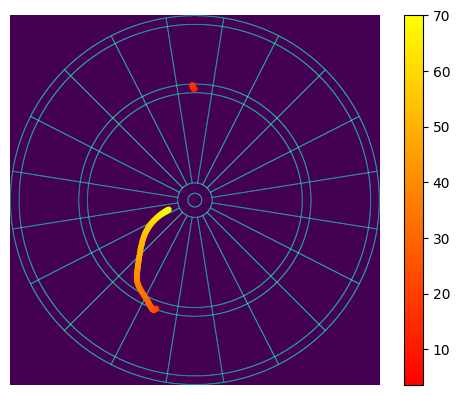

In [74]:
board_plot(board, exp_df.iloc[10:], 'exp_coords', 250)

The following video shows how the heat map of expected score changes as $\sigma$ increases - the frames are normalized so that the brightest colour corresponds to the current largest expected score. This makes the change in the heat map easier to see, and shows how the optimal aiming point moves up towards the bullseye in the limit of $\sigma\rightarrow\infty$.

In [5]:
import matplotlib.animation as animation
from IPython.display import HTML

In [19]:
def exp_animation(board, sigma_min, sigma_max, sigma_points, interval):
    images = []
    fig = plt.figure(figsize=(10, 10))
    borders = convolve2d(board, np.array([[1,1,1],[1,-8,1],[1,1,1]]), mode='same')
    borders = borders == 0
    
    sigma_range = np.linspace(sigma_min, sigma_max, sigma_points)
    for sigma in tqdm(sigma_range):
        sigma_pxl = sigma / mm_per_pixel
        
        mu = np.array([0, 0])
        Sigma = sigma_pxl*sigma_pxl*np.eye(2)
        exp = expected_score(board, mu, Sigma, padding=200)
    
        i, j = np.unravel_index(exp.argmax(), exp.shape)
        images.append((plt.imshow(exp*borders, cmap='plasma', animated=True, origin='lower'), 
                       plt.scatter(j, i, c='b'),
                       plt.text(100, 100, f'σ = {sigma:.2f}', color='white')))

    ani = animation.ArtistAnimation(fig, images, interval=interval, blit=True,
                                    repeat_delay=1000)
    
    ani.save('exp_movie.mp4')
    return HTML(ani.to_html5_video())

100%|████████████████████████████████████████████████████████████████████████████████| 100/100 [04:56<00:00,  2.96s/it]


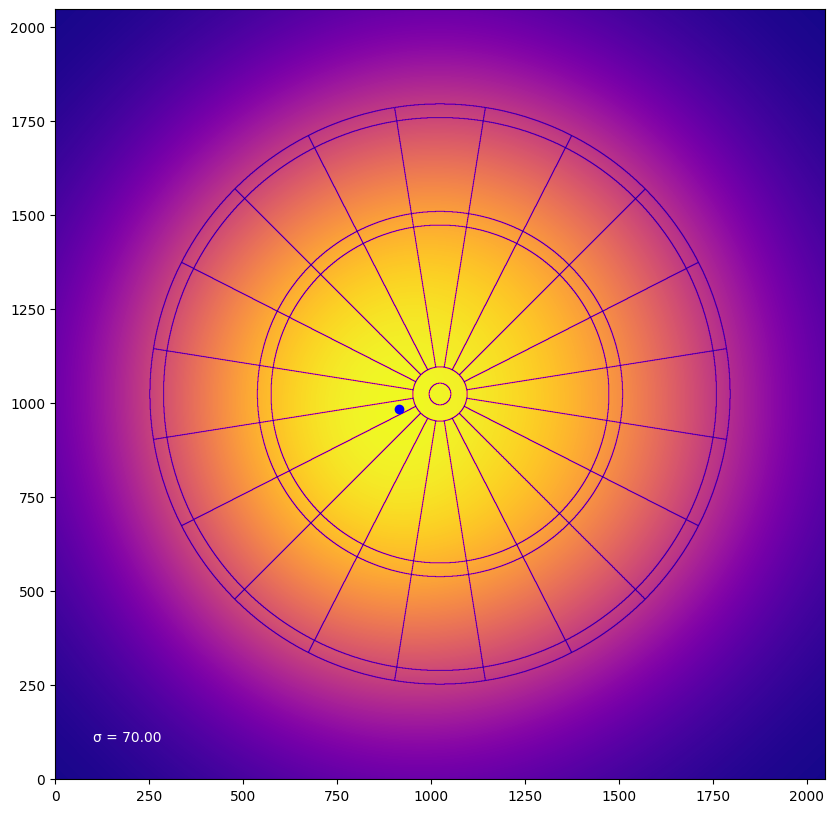

In [20]:
exp_animation(board, 1, 70, 100, 100)

## General $\Sigma$

The analysis up until now has focussed entirely on a particular kind of throwing distribution - specifically, distributions which are spherically symmetric, and so parameterised by a single parameter $\sigma$:

$$
\Sigma_{sph} = \sigma^{2}\mathrm{I}
$$

This has been convenient, as means that the player's skill is represented by the single parameter $\sigma$, making it easier to visualise performance as a function of skill. Of course, it is possible to model the player's throwing distribution using a more general set of throwing distributions, by allowing $\Sigma$ to be any symmetric positive semi-definite matrix. In fact, as pointed out in ASPD, this is likely to be observed in the throwing distributions of real players:

- There is usually a larger variance in the vertical direction than the horizontal direction, as it is harder to account for the additional affect of gravity on the dart in this direction. So a more representative throwing distribution can be modelled using a diagonal covariance matrix with distinct horizontal and vertical variances:

$$
\Sigma = \begin{pmatrix}
\sigma_h^2 & 0\\
0 & \sigma_v^2
\end{pmatrix}
$$

- A general covariance matrix $\Sigma$ with off-diagonal components may be needed to fully represent the throwing distribution of a player. For example, for a right-handed player, the angle that the forearm makes with the vertical when throwing dart may influence the accuracy in a direction no parallel to the vertical or horizontal axes. In fact, the authors of ASPD find exactly this when measuring their own personal observed throwing distributions (see Figure 4 in their paper).


- The authors of ASPD also investigate alternative, non-Gaussian models which are able to capture effects such as skewness, not represented in the simplified Gaussian model. However, they find that the added complexity does not provide much additional value over the Gaussian model.


- The assumption of a constant throwing distribution may also be a too restrictive assumption. There are ways in which one might expect the parameters of the distribution to change, both in space (e.g. when aiming at different parts of the board, such as a double) and in time (when the player has had a chance to 'warm up').

In the case of a general positive-definite symmetric covariance matrix $\Sigma$, we can visualize the heat map and recommended aiming point in the same way as before. For example, here is the heat map for the throwing distribution with non-diagonal covariance given by:

In [105]:
Sigma = np.array([[400, 500], [500, 900]]) # note: units here are pixels, not mm

As mentioned earlier, this has a larger variance in the vertical direction, and has a slight leftwards tilt corresponding to a right-handed player. We see that the triple 15 is recommended now, due to the smaller variance in the direction in the direction perpendicular to the 15 segment.

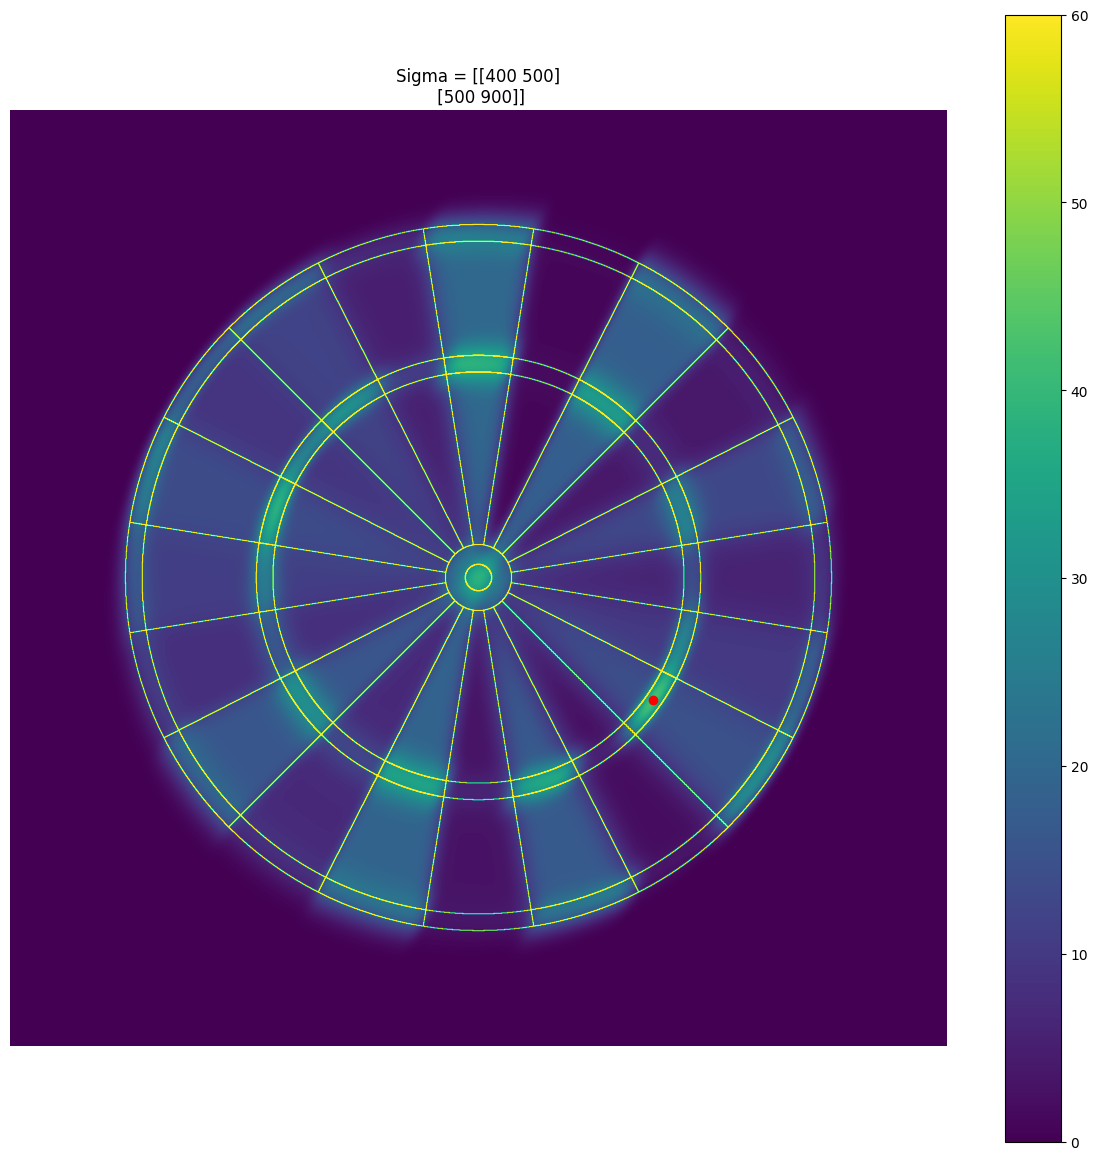

In [106]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(12, 12))

# Used to plot the dartboard region borders
borders = convolve2d(board, np.array([[1,1,1],[1,-8,1],[1,1,1]]), mode='same')
borders = borders != 0

# Define throwing distribution
mu = np.array([0, 0])

# Expected score
exp = expected_score(board, mu, Sigma, padding=100)
i, j = np.unravel_index(np.argmax(exp), board.shape)

# Plot the heat maps
im = ax.imshow(exp + 60*borders, origin='lower', vmin=0, vmax=60)
ax.scatter(j, i, color='red')
ax.axis('off')
ax.set_title(f'Sigma = {Sigma}')

fig.tight_layout() 
fig.colorbar(im, ax=ax)

## Aiming at the Quadro board

The analysis performed above can be applied just as well to the Quadro board - as a reminder, this board has an additional ring between the centre and the triple ring which quadruples the score of the segment:

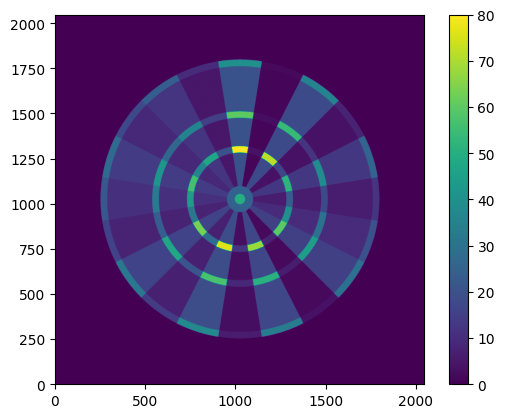

In [9]:
quadro, _ = generate_dartboard(2048, quadro=True)

plt.imshow(quadro, origin='lower')
plt.colorbar()

For the same values of $\sigma$ plotted earlier, we can visualize the heat maps for this new board. We find that the recommended points that players of each skill level should aim for are modified by the inclusion of more tempting scoring regions:

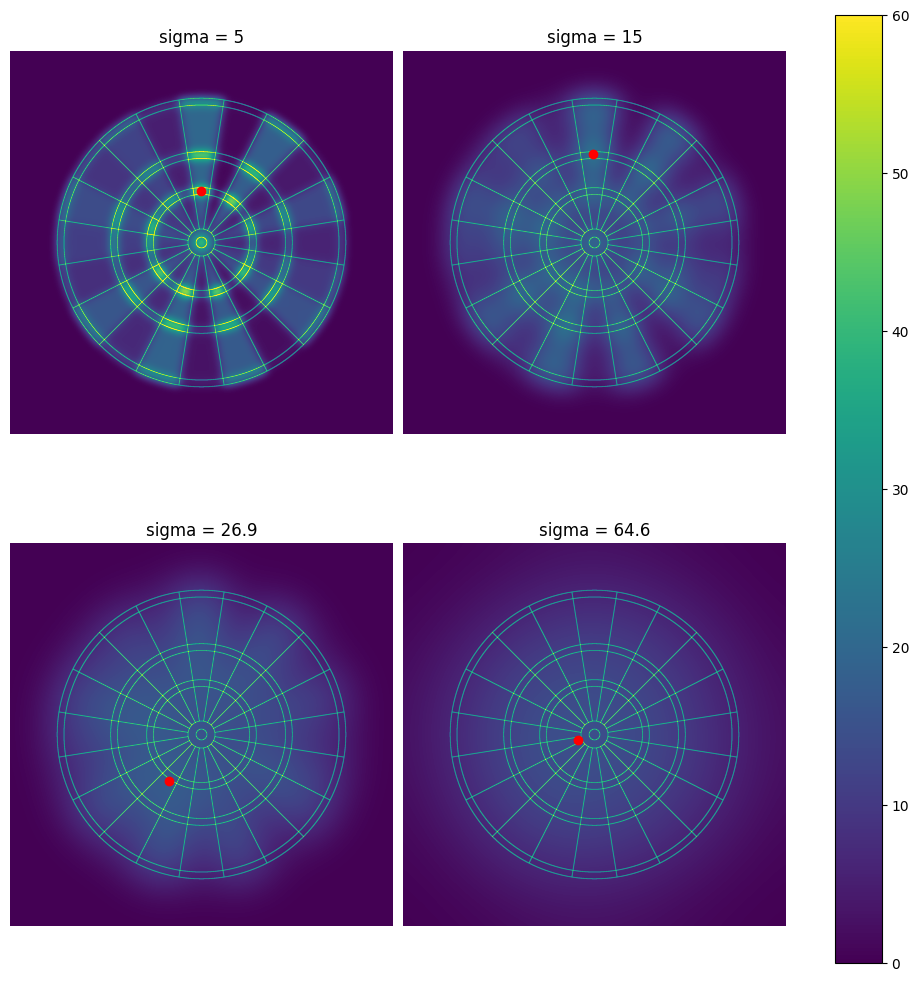

In [10]:
plot_heat_map([5, 15, 26.9, 64.6], quadro, mm_per_pixel, plot_shape=(2,2), fig_args={'figsize': (10, 10)})

Clearly, very strong players are incentivised to aim for the quadruple in order to maximise their expected scores. Even weaker players are seen to take advantage of the quaduple 19 (over the triple 19) to increase their expected scores. We can again visualize the expected score (and standard deviation) for a single dart throw, for a range of $\sigma$ values representing players of varying skills:

In [11]:
mu = np.zeros(2)
Sigma = np.eye(2)

quadro_coords = []
quadro_exps = []
quadro_stds = []

sigma_range = np.linspace(0.1, 70, 200)

for sigma_mm in tqdm(sigma_range):
    sigma_pxl = sigma_mm / mm_per_pixel
    exp = expected_score(quadro, mu, sigma_pxl*sigma_pxl*Sigma, padding=200)
    std = std_score(quadro, mu, sigma_pxl*sigma_pxl*Sigma, padding=200)

    # Coordinates of maximum expected score
    i, j = np.unravel_index(exp.argmax(), exp.shape)
    
    quadro_exps.append(np.max(exp))
    quadro_stds.append(std[i, j])
    quadro_coords.append((j, i))

100%|████████████████████████████████████████████████████████████████████████████████| 200/200 [14:18<00:00,  4.29s/it]


In [12]:
quadro_df = pd.DataFrame(list(zip(sigma_range, quadro_exps, quadro_stds, quadro_coords)), 
                      columns=['sigma', 'exp_score', 'std_score', 'coords']
                     ).set_index('sigma')

<Axes: xlabel='sigma', ylabel='Points'>

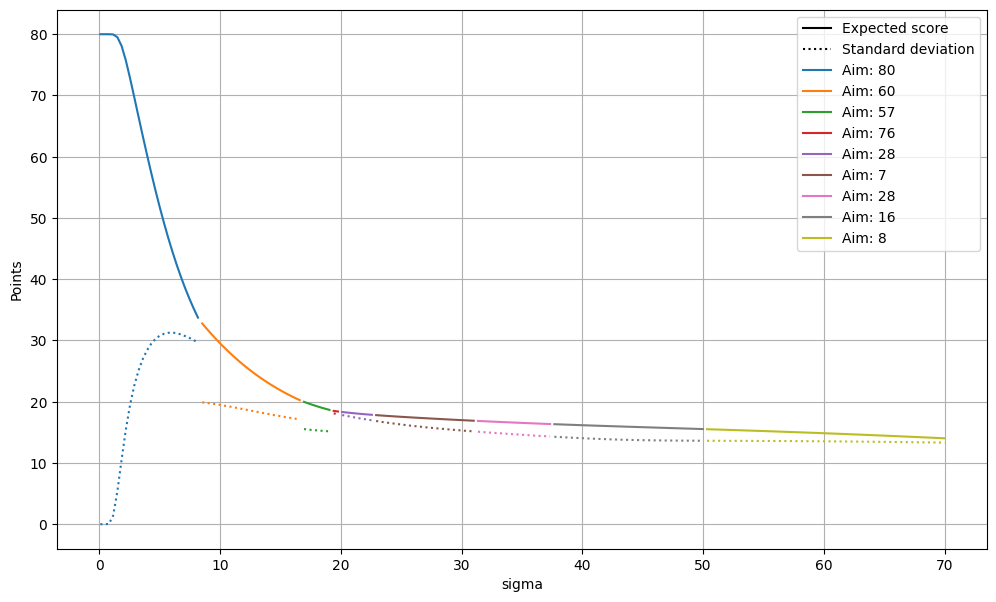

In [62]:
plot_col_against_sigma('exp_score', 'coords', quadro_df, quadro, ['std_score'], fig_args={'figsize': (12, 7)})

Also plotted is the path of optimal aim point across the face of the board, as $\sigma$ increases:

(<Figure size 1000x1000 with 2 Axes>, <Axes: >)

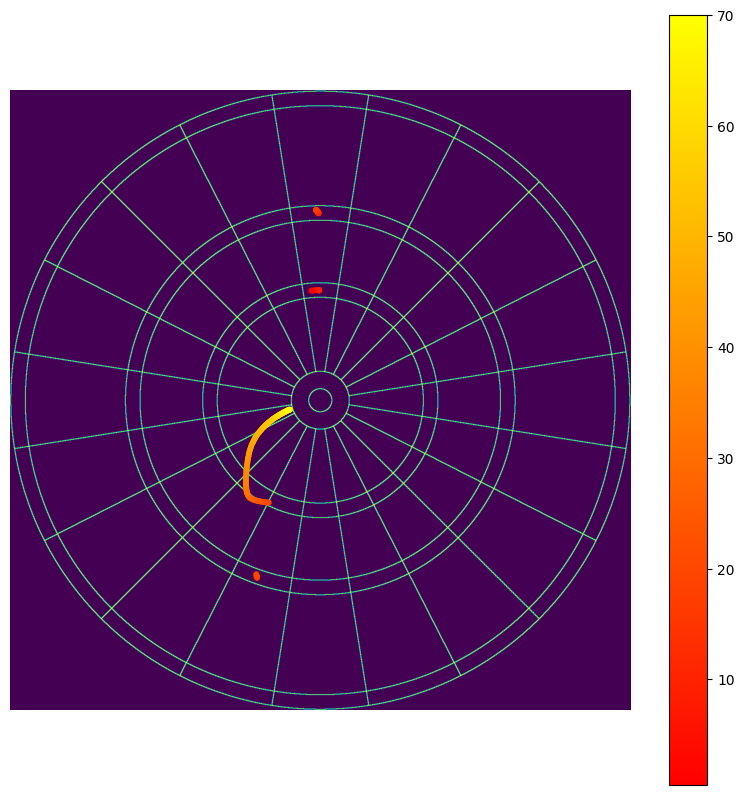

In [77]:
board_plot(quadro, quadro_df.iloc[1:], 'coords', 250, fig_args={'figsize': (10, 10)})

The takeaways from these plots are:

- The strongest players aim for the quadruple 20 (no surprises there).
- At $\sigma=8.5$mm, the recommendation is to aim for the triple 20 instead of the quadruple 20. This is probably due to the larger area of the triple 20 region, reducing the probability of missing the 20 segment entirely and scoring a low score in the 1 or 5 segment.
- At $\sigma\approx17$mm, the player should aim for the triple 19, instead of the triple 20. The matches very closely to the recommendation given by the analysis for the standard board.
- At $\sigma=19.4$mm (not long after the previous jump to the triple 19), the recommendation is to switch to the quadruple 19.
- As $\sigma$ increases further, the expected score obtained does not decrease significantly, dropping only by a few point between $\sigma=20$mm and $\sigma=70$mm. The optimal aim point drifts left into the quadruple 7 region, before drifting upwards towards the centre of the dartboard as the variance grows.

## Quadro vs standard board

What can we conclude about the 1-dart strategy on the Quadro board, compared to the standard dartboard? For very good players (such as professionals), it is certainly harder to know for sure whether to aim for the quadruple 20 or triple 20 without a good estimate of their throwing variances. At a relatively small value of $\sigma$ (less than 1cm), the recommendation from the simplified symmetric Gaussian analysis is that the player is best off aiming for the triple 20, rather than the quadruple 20. This suggests that, at least for very strong players, the addition of the quadruple scoring regions may not affect the optimal strategy that much, negating the motivation for introducing the board.

For less strong players, and even for enthusiastic amateurs, the strategy does appear to have changed slightly; players are recommended to aim for the quadruple 19 region over the triple 19. The expected score does not change that much when compared to the standard dartboard - for example, for a player with $\sigma=25mm$ has an expected score of 15.8 points on the standard dart board, and 17.5 on the Quadro board, less than 2 additional average points. The standard deviations are slightly more distinct (12.7 for the standard board, 16.3 for the Quadro board), capturing the increased variance that comes from aiming at the smaller quadruple ring, and the corresponding differences in scores either side of the quadruple ring wire. For the amateur player, the addition of the quadruple ring could be argued to add some additional excitement, and potentially allow weaker players to get lucky against stronger players more frequently.